# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Data

In [3]:
sorted([f for f in sorted(os.listdir('data')) if f.startswith('df_bc')])

['df_bc_2026-02-05-15h.pickle',
 'df_bc_2026-02-05-17h.pickle',
 'df_bc_2026-02-05-18h.pickle',
 'df_bc_2026-02-05-19h.pickle',
 'df_bc_2026-02-06-11h.pickle',
 'df_bc_2026-03-05-13h.pickle',
 'df_bc_2026-03-06-10h.pickle',
 'df_bc_2026-03-06-12h.pickle',
 'df_bc_feat_names_2026-02-05-15h.csv',
 'df_bc_feat_names_2026-02-05-17h.csv',
 'df_bc_feat_names_2026-02-05-18h.csv',
 'df_bc_feat_names_2026-02-05-19h.csv',
 'df_bc_feat_names_2026-02-06-11h.csv',
 'df_bc_feat_names_2026-03-05-13h.csv',
 'df_bc_feat_names_2026-03-06-10h.csv',
 'df_bc_feat_names_2026-03-06-12h.csv']

In [4]:
version = '2026-03-06-12h'
print(version)

all_feat_names = pd.read_csv(f"data/df_bc_feat_names_{version}.csv").columns[1:]
df = pd.read_pickle(f"data/df_bc_{version}.pickle")
print(df.shape)
print(df.columns)
for f in all_feat_names:
    assert f in df.columns

df.head()

2026-03-06-12h
(46401, 143)
Index(['ew', 'post_has_cal', 'post_has_axon', 'row', 'link', 'nuc', 'status',
       'status_alt', 'req_review', 'ais',
       ...
       'tsne_d1', 'leiden_cluster', 'leiden_fine_cluster', 'ood_rel',
       'ood_abs', 'abs_ood_rel', 'abs_ood_abs', 'merged_cluster_str',
       'merged_cluster', 'final_cluster'],
      dtype='object', length=143)


,ew,post_has_cal,post_has_axon,row,link,nuc,status,status_alt,req_review,ais,...,tsne_d1,leiden_cluster,leiden_fine_cluster,ood_rel,ood_abs,abs_ood_rel,abs_ood_abs,merged_cluster_str,merged_cluster,final_cluster
cell,,,,,,,,,,,,,,,,,,,,,
720575940536773811,2,1,0,None,None,74386772452474253,ok,yes,None,None,...,80.858246,0,0,-1.102659,-10.73560,1.102659,10.73560,0,0.0,t7
720575940536809651,2,1,0,None,None,72977679582305120,ok,yes,None,None,...,-53.494343,1,3,1.138120,10.67870,1.138120,10.67870,1,1.0,t6
720575940536909747,2,1,0,None,None,75085855689532315,ok,yes,None,None,...,-7.995934,2,8,-0.768618,-4.87650,0.768618,4.87650,2-3-4-5,11.0,RBC
720575940537001907,2,1,0,None,https://spelunker.cave-explorer.org/#!middleau...,76002092405412019,ok,yes,None,None,...,12.271126,6,10,-0.359557,-4.31735,0.359557,4.31735,6,12.0,t5t
720575940537052083,2,1,0,None,None,73960986574906904,Worst,no,None,None,...,NaN,None,None,0.000000,0.00000,0.000000,0.00000,NaN,NaN,NaN


In [5]:
list(df.columns)

['ew',
 'post_has_cal',
 'post_has_axon',
 'row',
 'link',
 'nuc',
 'status',
 'status_alt',
 'req_review',
 'ais',
 'cellclass',
 'cellclass_alt',
 'celltype',
 'celltype_alt',
 'celltype_conf',
 'ew1type',
 'ew1type_conf',
 'soma_annot_x_um',
 'soma_annot_y_um',
 'soma_annot_z_um',
 'soma_layer',
 'cutoff_severity',
 'branch_points',
 'tips',
 'total_length',
 'total_surface',
 'total_volume',
 'max_branch_order',
 'tree_asymmetry',
 'max_segment_path_length',
 'median_intermediate_segment_pl',
 'median_terminal_segment_pl',
 'radius_median',
 'radius_mean',
 'radius_std',
 'radius_q5',
 'radius_q95',
 'path_angle_median',
 'path_angle_mean',
 'path_angle_std',
 'path_angle_q5',
 'path_angle_q95',
 'tortuosity_median',
 'tortuosity_mean',
 'tortuosity_std',
 'tortuosity_q5',
 'tortuosity_q95',
 'branch_angle_median',
 'branch_angle_mean',
 'branch_angle_std',
 'branch_angle_q5',
 'branch_angle_q95',
 'max_path_dist_to_soma',
 'mean_soma_exit_angle',
 'hull_perimeter',
 'hull_area',
 

In [5]:
assert not df.columns.duplicated().any()

In [6]:
[c for c in df.columns if 'PC' in c]

['z-PC0',
 'z-PC1',
 'z-PC2',
 'z-PC3',
 'z-PC4',
 'z-PC5',
 'z-PC6',
 'z-PC7',
 'z-PC8',
 'z-PC9',
 'z-PC10',
 'z-PC11',
 'norm-z-PC0',
 'norm-z-PC1',
 'norm-z-PC2',
 'norm-z-PC3',
 'norm-z-PC4',
 'norm-z-PC5',
 'norm-z-PC6',
 'norm-z-PC7',
 'norm-z-PC8',
 'norm-z-PC9',
 'norm-z-PC10',
 'norm-z-PC11']

## Add hull-centers

In [7]:
from eyewire2_morphological_clustering.utils.mosaics import polygon_centroid

df['hull_center'] = df.hull_points.apply(polygon_centroid)
df['hull_center_x'] = df['hull_center'].apply(lambda x: x[0])
df['hull_center_y'] = df['hull_center'].apply(lambda x: x[1])

# Labels

### Select subset for plotting

In [8]:
plot_order = ['t1', 'GluMI', 't2', 't3a', 't3b', 't4', 't5o', 't5t', 't5i', 'XBC', 't7', 't6', 't8', 't9', 'RBC']

In [9]:
#celltype_plot = 'final_cluster'
celltype_plot = 'celltype'

#df = df[df['final_cluster']!="11"]
#df.loc[df['final_cluster']=="4", 'final_cluster'] = 't9'

df = df[df[celltype_plot].isin(plot_order)]

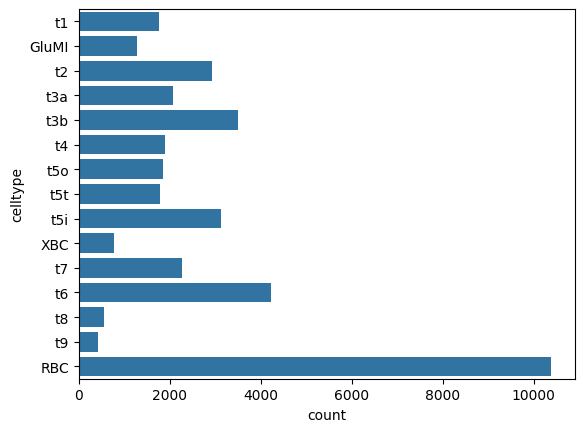

In [10]:
sns.countplot(df, y=celltype_plot, order=plot_order);

### Collect labels

In [11]:
human_labels = np.array(df[celltype_plot].values)
df['is_labelled'] = df[celltype_plot].notnull()

# Figures

In [12]:
from eyewire2_morphological_clustering.utils.style import set_rc_params

set_rc_params()

In [13]:
fig_dir = f'figures/bc_{version}'
os.makedirs(fig_dir, exist_ok=True)

In [14]:
from eyewire2_morphological_clustering.utils.colors import cellclass2color

# Dendrograms

In [15]:
all_feat_names

Index(['z-PC0', 'z-PC1', 'z-PC2', 'z-PC3', 'z-PC4', 'z-PC5', 'z-PC6', 'z-PC7',
       'z-PC8', 'z-PC9', 'z-PC10', 'z-PC11', 'log_z_dens_sum',
       'log_hull_diameter', 'log_hull_perimeter', 'log_tips',
       'log_radius_mean', 'log_radius_median', 'log_radius_std',
       'log_radius_q5', 'log_radius_q95'],
      dtype='object')

In [16]:
all_feat_names_norm = ['norm-' + f for f in all_feat_names]
all_feats_norm = df.loc[:, all_feat_names_norm].values

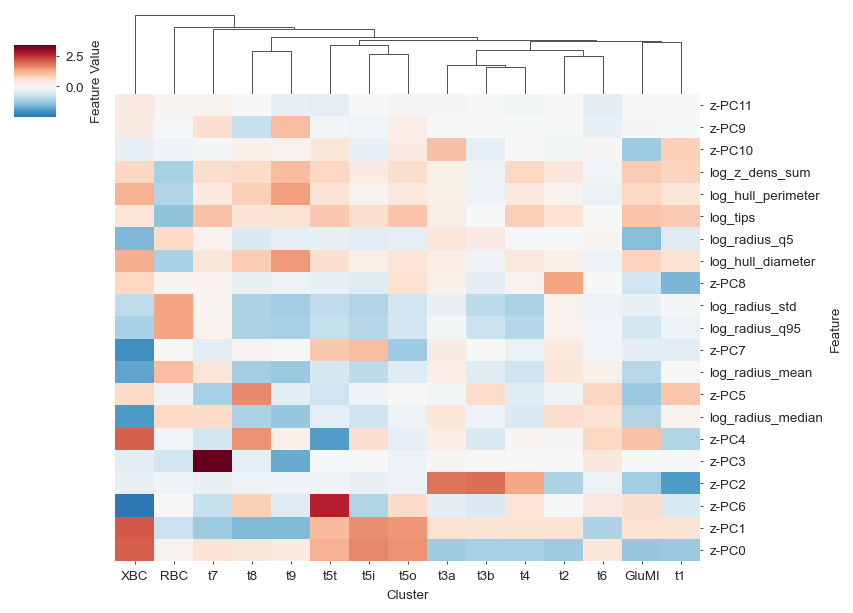

In [17]:
from eyewire2_morphological_clustering.utils.dendrogram import ClusterDendrogram

cd = ClusterDendrogram(
    data=all_feats_norm[df.is_labelled],
    cluster_labels=df[celltype_plot][df.is_labelled],
    feature_names=all_feat_names,
)
avg_features = cd.compute_cluster_averages(log_transform=False)
filtered_features, selected_features = cd.filter_features(verbose=False)
dist_matrix = cd.compute_distance_matrix(metric='euclidean')
Z = cd.hierarchical_cluster(method='average')

# fig1, dendro = cd.plot_dendrogram(figsize=(7, 2))
fig2 = cd.plot_heatmap_with_dendrogram(top_n_features=50, figsize=(7, 5))

plt.show()

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage

dendro = dendrogram(
    cd.Z,
    labels=cd.clusters,
    leaf_font_size=8,
    color_threshold=0,
    above_threshold_color='gray',
    no_plot=True,
)

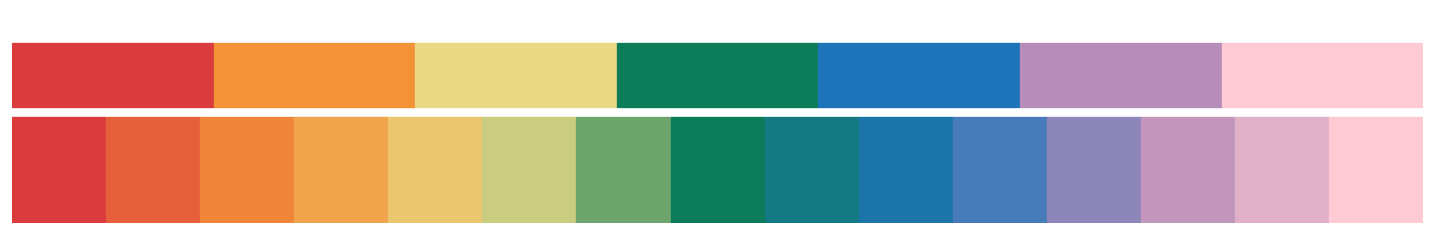

In [19]:
from eyewire2_morphological_clustering.utils import colors

interpolated_colors = colors.interpolate_colors(n=len(plot_order))
ordered_colors = colors.reorder_colors_for_distinction(interpolated_colors, n_neighbors=4)

label2color = {leaf_name: ordered_colors[i] for i, leaf_name in enumerate(plot_order)}

In [20]:
label2color

{'t1': '#da3b3c',
 'GluMI': '#1b75ab',
 't2': '#ffcad4',
 't3a': '#8d86b8',
 't3b': '#f0a54c',
 't4': '#6ca46c',
 't5o': '#0c7c5a',
 't5t': '#e0b0c8',
 't5i': '#487bb9',
 'XBC': '#e5603a',
 't7': '#ecc56f',
 't6': '#137983',
 't8': '#c195bc',
 't9': '#ef8538',
 'RBC': '#cacc7f'}

## Plot

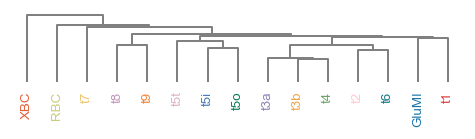

In [21]:
fig, ax = plt.subplots(figsize=(4, 1.2))
sns.despine(left=True, bottom=True, right=True, top=True)

# Plot dendrogram
dendro = dendrogram(
    cd.Z,
    labels=cd.clusters,
    ax=ax,
    leaf_font_size=8,
    color_threshold=0,
    above_threshold_color='gray',
    no_plot=False,
)

ax.tick_params("x", rotation=90)
xlabels = ax.get_xmajorticklabels()
xlabelnames = []
for label in xlabels:
    label.set_color(label2color[label.get_text()])

assert len(np.unique(xlabelnames)) == len(xlabelnames)


ax.set_yticks([])
plt.tight_layout()

fig.savefig(f'{fig_dir}/bc-dendrogram.svg')
fig.savefig(f'{fig_dir}/bc-dendrogram.png', dpi=600)

# Nearest neighbors

Removed 1 outlier for ct='t1'
Removed 1 outlier for ct='t3a'
Removed 1 outlier for ct='t5i'
Removed 1 outlier for ct='t8'
Removed 2 outlier for ct='t9'
Removed 6 outlier for ct='RBC'


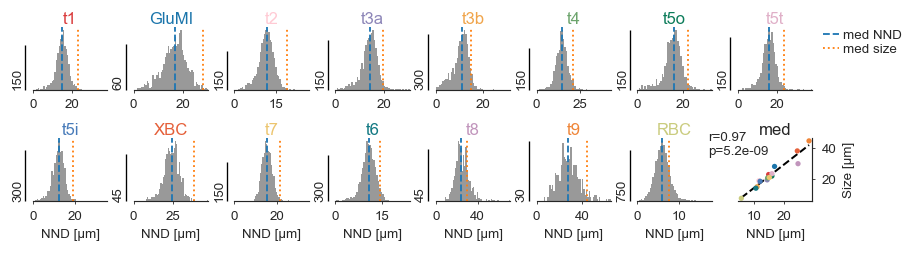

In [116]:
import matplotlib.ticker as ticker
from scipy.spatial import cKDTree
from scipy import stats


def add_scale_bar(ax, x_pos, x_pos_text, max_val, n_ticks=3):
    """Draw a vertical scale bar with a single label."""
    import math
    magnitude = 10 ** math.floor(math.log10(max_val)) if max_val > 0 else 1
    scale = round(max_val / magnitude * 0.5) * magnitude / 2
    if scale == 0:
        scale = magnitude / 2
    tick_values = [i * scale for i in range(n_ticks + 1) if i * scale <= max_val * 1.05]
    bar_height = tick_values[-1]
    ax.plot([x_pos, x_pos], [0, bar_height], color="black", solid_capstyle='butt', lw=0.8, clip_on=False)
    ax.text(x_pos_text, 0, f"{int(bar_height)}", ha="right", va="bottom", fontsize=8, rotation=90)


def plot_nnd_histograms(df, celltypes,
                        center_x_col="hull_center_x",
                        center_y_col="hull_center_y",
                        diameter_col="hull_diameter",
                        celltype_col="celltype"):

    df = df[df.is_labelled].copy()
    nrows = min(2, len(celltypes) + 1)
    ncols = int(np.ceil((len(celltypes) + 1) / nrows))

    fig, axs = plt.subplots(nrows, ncols, figsize=(7.5, nrows * 1), squeeze=False)
    sns.despine(fig=fig)
    nnd_medians = {}
    dia_medians = {}

    for idx, ct in enumerate(celltypes):
        ax = axs[idx // ncols, idx % ncols]
        sub = df[df[celltype_col] == ct].dropna(subset=[center_x_col, center_y_col])

        # ── NND ──────────────────────────────────────────────────────────
        dists, _ = cKDTree(
            sub[[center_x_col, center_y_col]].values).query(
            sub[[center_x_col, center_y_col]].values, k=2)
        nnd = dists[:, 1]
        nnd_median = np.median(nnd)

        ood = nnd > 3 * nnd_median
        if np.any(ood):
            print(f"Removed {np.sum(ood)} outlier for {ct=}")
            nnd = nnd[~ood]

        # vertical histogram: values on x-axis
        sns.histplot(
            x=nnd, bins=51, ax=ax,
            color="gray", alpha=0.80,
            edgecolor="none", linewidth=0)
        ax.set(xlabel=None, ylabel=None)

        nnd_medians[ct] = np.median(nnd)
        ax.axvline(nnd_median, color="C0",
                   linewidth=1.1, linestyle="--", label="med NND")

        ax.set_xlim(0, np.nanmax(nnd))

        # ── Dendritic field size ─────────────────────────────────────────
        dia_median = np.median(sub[diameter_col].dropna())
        ax.axvline(dia_median, color="C1",
                   linewidth=1.1, linestyle=":", label="med size")

        dia_medians[ct] = dia_median

        ax.set_title(f"{ct}", color=label2color[ct], pad=1)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(2))
        ax.xaxis.set_major_locator(ticker.MaxNLocator(2))

        if idx == (ncols - 1):
            ax.legend(frameon=False, loc="upper left", handlelength=1.2, bbox_to_anchor=(1.1, 1))

        x_pos = ax.get_xlim()[0] - 0.1 * np.diff(ax.get_xlim())
        x_pos_text = ax.get_xlim()[0] - 0.12 * np.diff(ax.get_xlim())
        add_scale_bar(ax, x_pos=x_pos, x_pos_text=x_pos_text, max_val=ax.get_ylim()[1], n_ticks=3)
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)

    for ax in axs[-1, :]:
        ax.set_xlabel("NND [µm]")

    for idx in range(len(celltypes), nrows * ncols):
        axs[idx // ncols, idx % ncols].set_visible(False)

    ax = axs[-1, -1]
    ax.set_visible(True)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    
    df_scatter = pd.DataFrame({"NND [µm]": nnd_medians, "Size [µm]": dia_medians}).reset_index()
    vmax = np.maximum(df_scatter['Size [µm]'].max(), df_scatter['NND [µm]'].max())

    slope, intercept, r, p, _ = stats.linregress(df_scatter['NND [µm]'], df_scatter['Size [µm]'])
    x_line = np.linspace(df_scatter['NND [µm]'].min(), df_scatter['NND [µm]'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, c='k', ls='--', zorder=-20)

    sns.scatterplot(df_scatter, x="NND [µm]", y="Size [µm]", clip_on=False,
                    hue='index', palette=label2color, legend=False, s=10, ec='none')
    #ax.set(label=None)
    ax.set_title('med', pad=1)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(True)

    fig.tight_layout(pad=0.4, h_pad=0.9, w_pad=0.4)

    ax.text(-0.4, 1.1, f"r={r:.2f}\np={p:.2g}", transform=ax.transAxes, va='top')

    return fig


fig = plot_nnd_histograms(df[df.is_labelled], celltypes=plot_order)

fig.savefig(f'{fig_dir}/BC_NND.svg', dpi=600, bbox_inches='tight')
fig.savefig(f'{fig_dir}/BC_NND.png', dpi=600, bbox_inches='tight')
plt.show()

# TSNE

/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/embedding.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  


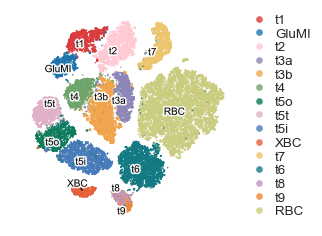

In [34]:
from eyewire2_morphological_clustering.utils.embedding import plot_embedding_v2

plot_embedding_v2(
    df=df,
    label2color=label2color,
    fig_path_prefix=f"{fig_dir}/bc-tsne",
    celltype_col=celltype_plot,
    plot_order=plot_order,
    is_labelled_col="is_labelled",
    dot_size=1,
    edgecolor="none",
    rasterized=True,
    legend_markerscale=4,
    figsize=(2.5, 2.3)
)

## Feature maps

In [24]:
example_feature_names = [
    'perc_z_025',
    'perc_z_050',
    
    #'norm-z-PC0',
    #'norm-z-PC1',
    #'norm-z-PC2',
    #'norm-z-PC3',
    #'norm-z-PC4',
    #'norm-z-PC5',
    #'norm-z-PC6',
    #'norm-z-PC7',
    
    'log_radius_median',
    'log_radius_q95',
    
    'log_tips',
    'log_hull_diameter',
    #'log_n_ribbons',
    
    
    #'perc_z_005',
    #
    #'log_median_intermediate_segment_pl',
    #'log_median_terminal_segment_pl',
    #'perc_z_025',
    #'perc_z_050',
]

example_features = df.loc[:, example_feature_names].values

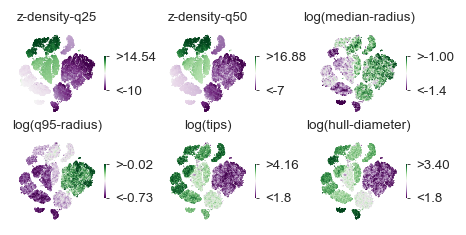

In [118]:
from eyewire2_morphological_clustering.utils.embedding import save_and_plot_feats

fig, axs = save_and_plot_feats(
    all_emb=df.loc[:, ['tsne_d0', 'tsne_d1']].values,
    all_feats=example_features,
    all_feat_names=example_feature_names, 
    ncols=3,
    clip=False,
    stride=1, 
    figsize_per_cell=(1.3, 1)
)

plt.tight_layout(h_pad=0.3)

fig.savefig(f'{fig_dir}/bc-tnse-features.svg', bbox_inches='tight')
fig.savefig(f'{fig_dir}/bc-tnse-features.png', dpi=600, bbox_inches='tight')

# Morph examples

## Select one per type

In [26]:
df['soma_rad_um'] = (df['soma_rad_a_um'] * df['soma_rad_b_um'] * df['soma_rad_c_um'])**(1/3) 

<Axes: >

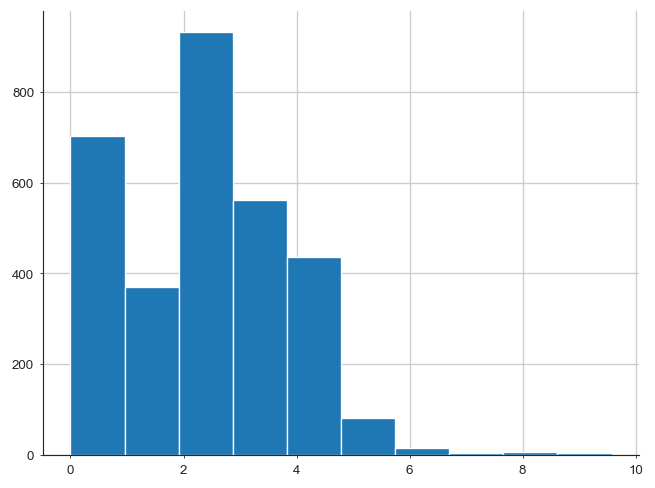

In [27]:
df.loc[df.post_has_soma == 1, 'soma_rad_um'].hist()

In [56]:
all_types_rows = []

for final_cluster in plot_order:
    rows = df[(df[celltype_plot] == final_cluster) & df.is_labelled & df.post_has_soma & ((df.soma_rad_um > 4) & (df.soma_rad_um < 6))]
    #rows = rows[rows.height >= np.percentile(rows.height, q=30)]
    
    if len(rows) == 0:
        rows = None
        print(celltype)

    if rows is None:
        row = None
    else:
        x = rows['tsne_d0']
        y = rows['tsne_d1']
        
        emb_ct = np.stack([x, y]).T
        
        ct_mean = np.mean(emb_ct, axis=0)
        ct_dists = np.sum((emb_ct - ct_mean) ** 2, axis=1) ** 0.5
        row = rows.iloc[np.argmin(ct_dists)]
        
    all_types_rows.append(row)
    
all_types_rows = pd.DataFrame(all_types_rows)
all_types_rows.head(2)

,ew,post_has_cal,post_has_axon,row,link,nuc,status,status_alt,req_review,ais,...,ood_abs,abs_ood_rel,abs_ood_abs,merged_cluster_str,merged_cluster,final_cluster,hull_center,hull_center_x,hull_center_y,soma_rad_um
720575940573913411,2,1,0,None,None,79523759430123082,ok,yes,None,None,...,6.8261,0.543393,6.8261,8,14.0,t1,"[870.9471, 848.62915]",870.947083,848.629150,5.105428
720575940560030130,2,1,0,None,None,76074385295077106,ok,yes,None,None,...,10.3942,0.547394,10.3942,16,9.0,GluMI,"[491.60617, 691.93146]",491.606171,691.931458,4.263715


0
6.9
Index([720575940573913411, 720575940560030130, 720575940556360242,
       720575940551443883, 720575940561072605, 720575940556607535,
       720575940557968476, 720575940560955472],
      dtype='int64')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


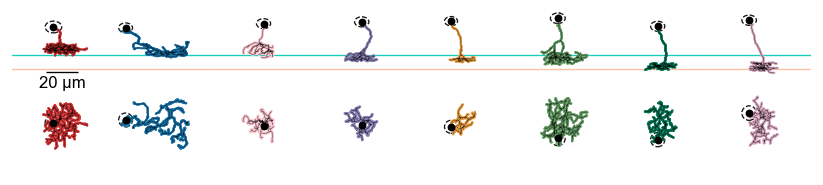

1
6.0375000000000005
Index([720575940578358294, 720575940552876357, 720575940573233696,
       720575940562402231, 720575940556610863, 720575940561798207,
       720575940575367320],
      dtype='int64')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


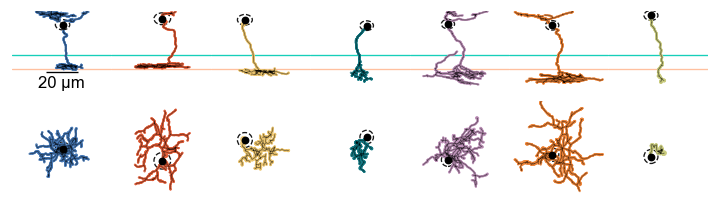

In [117]:
from eyewire2_morphological_clustering.utils.plot_cells import plot_rows

nrows = 2
ncols = int(np.ceil(len(all_types_rows) / nrows))

rad = (all_types_rows.hull_diameter.max() / 2) * 1.3

for i in range(nrows):
    print(i)
    rows = np.array_split(all_types_rows, nrows)[i]
    
    width = 6.9 * rows.shape[0] / ncols
    print(width)
    
    fig, axs = plt.subplots(
        2, len(rows), figsize=(width, 2.3), sharex='all', sharey='row', squeeze=False, height_ratios=(1.7, 4),
        subplot_kw=dict(xlabel=None, ylabel=None, xticks=[], yticks=[]), layout='tight')
    for ax in axs.flat:
        ax.axis('off')
    print(rows.index.astype(int))
    fig, _ = plot_rows(
        rows=rows, rad=rad, size=20, fig=fig, axs=axs,
        color_list=[label2color[ct] for ct in rows[celltype_plot].values],
        show_on_tsne=False
    )

    #for j, ax in enumerate(axs[0, :]):
    #    ax.set_title(rows.iloc[j][celltype_plot], fontsize=8)

    fig.tight_layout(w_pad=0, h_pad=-0.5)

    if i == 0:
        shift_up = 0.1
        for ax in axs[-1, :]:
            pos = ax.get_position()
            ax.set_position([pos.x0, pos.y0 + shift_up, pos.width, pos.height])

    
    fig.savefig(f'{fig_dir}/celltype-example_set{i}({nrows}).svg', dpi=800, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/celltype-example_set{i}({nrows}).png', dpi=800, bbox_inches='tight')
    
    plt.show()

# Coverage

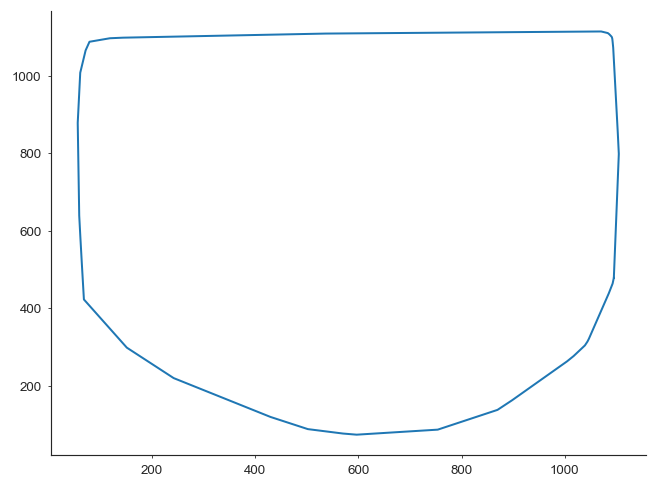

In [95]:
from scipy.spatial import ConvexHull

pts = np.vstack(df.hull_points)[:, :2]
hull = ConvexHull(pts)

# Get hull boundary points in order, closed
hull_pts = pts[np.append(hull.vertices, hull.vertices[0])]
plt.plot(*hull_pts.T)
plt.show()

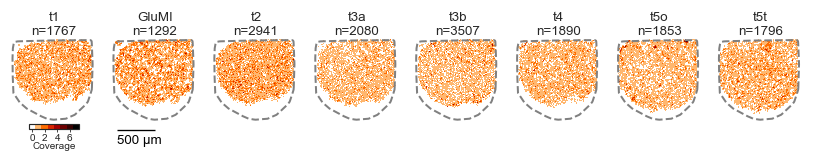

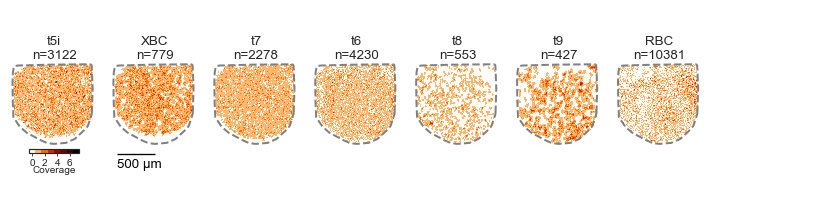

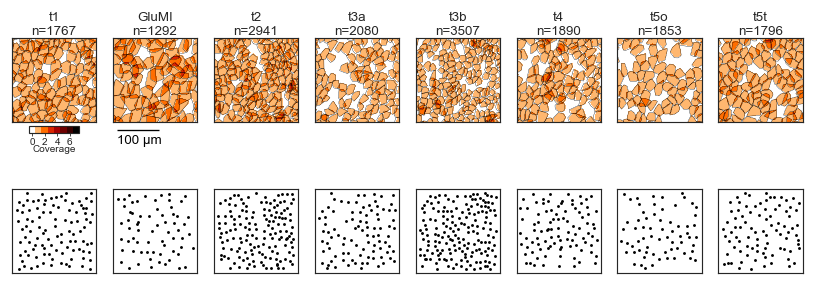

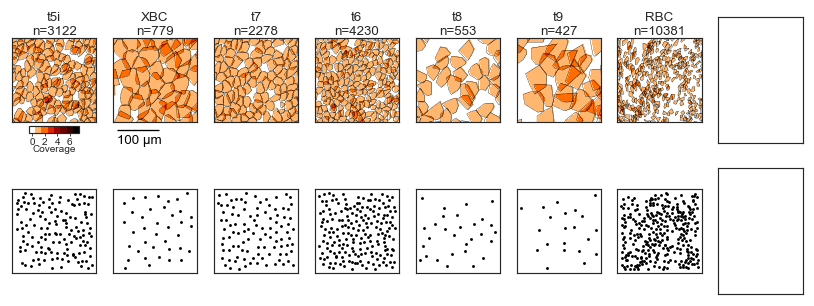

In [115]:
from eyewire2_morphological_clustering.utils.mosaics import plot_multiple_mosaics

max_val = 7

for name, extent in {'wide': [50, 1150, 50, 1150], 'zoom': [200, 400, 600, 800], }.items(): # 'zoom2': [200, 300, 600, 700], 

    for i in range(nrows):
        celltypes = np.array_split(plot_order, nrows)[i]

        plot_bodies = 'zoom' in name.lower()
        
        fig, axs = plt.subplots(ncols=ncols, nrows=2 if plot_bodies else 1,
                                figsize=(8.5, 3 if plot_bodies else 2),
                                sharex='row', sharey='row', squeeze=False)    
        if 'wide' in name.lower():
            sns.despine(top=True, right=True, left=True, bottom=True)
        else:
            sns.despine(top=False, right=False, left=False, bottom=False)
        
        ims, c_maxs = plot_multiple_mosaics(
            df=df[df.is_labelled],
            celltype_col='celltype',
            celltypes=celltypes,
            fig=fig,
            coverage_axs=axs[0, :],
            resolutions=[1000] * ncols,
            center_axs=axs[1, :] if plot_bodies else None,            
            title_axs=axs[0, :],
            sb_axs=[axs[0, 1]],
            center_x_col="hull_center_x",
            center_y_col="hull_center_y",
            marker_sizes=np.ones(ncols) * (0.1 if 'wide' in name.lower() else 3),
            max_val=max_val,
            extent=extent,
            plot_outlines='zoom' in name.lower(),
            outline_hull=hull_pts if 'wide' in name.lower() else None,
            cb=True,
            sb_size=500 if 'wide' in name.lower() else 100,
        )
        
        fig.savefig(f'{fig_dir}/bc-{celltypes}_set{i}({nrows})_{extent}.svg', dpi=600, bbox_inches='tight')
        fig.savefig(f'{fig_dir}/bc-{celltypes}_set{i}({nrows})_{extent}.png', dpi=600, bbox_inches='tight')
        plt.show()

# Copy files

In [102]:
import shutil

shutil.copytree(fig_dir, f"/gpfs01/euler/data/Resources/Eyewire2/figures/{fig_dir}", dirs_exist_ok=True)

'/gpfs01/euler/data/Resources/Eyewire2/figures/figures/bc_2026-03-06-12h'

In [ ]:
fig_dir